# Milk Quality Analysis and Classification Using Machine Learning
**B.Tech CSE Semester V — Machine Learning Case Study Project**

---

### **1. Executive Overview & Problem Statement**
Milk is a perishable dairy product whose quality directly influences public health, food safety, and industrial processing viability. Quality deterioration is driven by bacterial fermentation, temperature mismanagement, lipid oxidation, and adulteration. Conventional analytical chemistry techniques (titration, microbial culture plates) require substantial incubation time and specialized laboratory apparatus.

This project develops an automated, data-driven machine learning system to classify milk quality into **Low**, **Medium**, or **High** grades based on seven measurable physical, chemical, and sensory properties:
1. **pH Level**: Indicator of acidity or alkalinity (normal fresh milk: 6.5–6.7).
2. **Temperature**: Thermal state during collection and storage (standard: 35–40°C).
3. **Taste**: Palatability index (1 = optimal, 0 = sour/abnormal).
4. **Odor**: Olfactory profile (1 = standard fresh aroma, 0 = pungent/off-flavor).
5. **Fat**: Lipid composition adequacy (1 = optimal fat content, 0 = deficient/skimmed).
6. **Turbidity**: Light dispersion caused by suspended casein micelles and fat globules (1 = turbid, 0 = clear).
7. **Colour**: Photometric reflectance index (240–255 scale; 255 = pure white).

---
### **Project Workflow**
```
Dataset Ingestion ➔ Data Understanding ➔ Data Quality Audit (Duplicate Paradox)
➔ Data Cleaning ➔ Exploratory Data Analysis ➔ Preprocessing & Leakage-Free Split
➔ 5-Fold Stratified Cross-Validation ➔ Model Evaluation & Comparison
➔ Confusion Matrix Diagnostics ➔ Feature Importance ➔ Error Analysis
➔ Model Serialization & Inference
```


In [1]:
# Core Scientific and Data Science Libraries
import os
import sys
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn Preprocessing, Models, and Evaluation
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

# Configuration for publication-ready visual aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Helvetica, Arial, DejaVu Sans'
plt.rcParams['figure.autolayout'] = True
%matplotlib inline

print("Libraries imported successfully.")


Libraries imported successfully.


### **2. Data Loading & Initial Inspection**
We load the primary Milk Quality dataset (`data/milk_quality.csv`), inspect raw column headers, dimensions, and data types.
Notice that the raw dataset contains spelling variations (e.g. `Temprature` instead of `Temperature`) and trailing spaces (e.g. `'Fat '`). We standardize column names immediately.


In [2]:
# Load dataset
data_path = '../data/milk_quality.csv'
if not os.path.exists(data_path):
    data_path = 'data/milk_quality.csv'

df_raw = pd.read_csv(data_path)
print(f"Dataset Raw Shape: {df_raw.shape} (Rows: {df_raw.shape[0]}, Columns: {df_raw.shape[1]})")
print("Original Raw Columns:", df_raw.columns.tolist())

# Clean column headers
df = df_raw.copy()
df.columns = [c.strip() for c in df.columns]
df = df.rename(columns={'Temprature': 'Temperature'})
df['Grade'] = df['Grade'].str.capitalize()

print("Standardized Columns:", df.columns.tolist())
df.head(10)


Dataset Raw Shape: (1059, 8) (Rows: 1059, Columns: 8)
Original Raw Columns: ['pH', 'Temprature', 'Taste', 'Odor', 'Fat ', 'Turbidity', 'Colour', 'Grade']
Standardized Columns: ['pH', 'Temperature', 'Taste', 'Odor', 'Fat', 'Turbidity', 'Colour', 'Grade']


,pH,Temperature,Taste,Odor,Fat,Turbidity,Colour,Grade
0,6.6,35,1,0,1,0,254,High
1,6.6,36,0,1,0,1,253,High
2,8.5,70,1,1,1,1,246,Low
3,9.5,34,1,1,0,1,255,Low
4,6.6,37,0,0,0,0,255,Medium
5,6.6,37,1,1,1,1,255,High
6,5.5,45,1,0,1,1,250,Low
7,4.5,60,0,1,1,1,250,Low
8,8.1,66,1,0,1,1,255,Low
9,6.7,45,1,1,0,0,247,Medium


### **3. Data Quality Audit & The Duplicate Paradox**
A critical responsibility in academic research is auditing data integrity. We examine:
1. Missing values (`NaN` counts)
2. Data types
3. Duplicate records
4. Numerical bounds


In [3]:
# 1. Missing Values Check
print("=== Missing Values Summary ===")
print(df.isnull().sum())

# 2. Data Types and Memory Usage
print("\n=== Data Information ===")
df.info()

# 3. Duplicate Records Audit
total_rows = len(df)
duplicate_rows = df.duplicated().sum()
unique_rows = total_rows - duplicate_rows
duplicate_pct = (duplicate_rows / total_rows) * 100

print(f"\n=== Duplicate Analysis ===")
print(f"Total Rows Ingested: {total_rows}")
print(f"Duplicate Rows Count: {duplicate_rows}")
print(f"Duplicate Percentage: {duplicate_pct:.2f}%")
print(f"Unique Physical Profiles: {unique_rows}")


=== Missing Values Summary ===
pH             0
Temperature    0
Taste          0
Odor           0
Fat            0
Turbidity      0
Colour         0
Grade          0
dtype: int64

=== Data Information ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1059 entries, 0 to 1058
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   pH           1059 non-null   float64
 1   Temperature  1059 non-null   int64  
 2   Taste        1059 non-null   int64  
 3   Odor         1059 non-null   int64  
 4   Fat          1059 non-null   int64  
 5   Turbidity    1059 non-null   int64  
 6   Colour       1059 non-null   int64  
 7   Grade        1059 non-null   object 
dtypes: float64(1), int64(6), object(1)
memory usage: 66.3+ KB

=== Duplicate Analysis ===
Total Rows Ingested: 1059
Duplicate Rows Count: 976
Duplicate Percentage: 92.16%
Unique Physical Profiles: 83


#### **Academically Grounded Preprocessing Decision: Duplicate Removal**
The duplicate audit reveals that **976 out of 1,059 rows (92.16%) are exact duplicate measurements**, corresponding to only **83 unique physical milk profiles**.

* **Why does this happen?** In many public datasets, repeated records result from automated sensor logging over time without changes in milk state, or synthetic oversampling.
* **The Data Leakage Risk:** If models are trained on all 1,059 rows with standard train-test splitting, identical records will appear in both training and test sets. The model simply memorizes records, producing an artificial ~99.5% accuracy that fails completely in real-world deployment.
* **Our Methodology:** We remove exact duplicates to train on the 83 distinct physical samples, ensuring rigorous, honest generalization.


In [4]:
# Deduplicate dataset
df_clean = df.drop_duplicates().reset_index(drop=True)
print(f"Shape before deduplication: {df.shape}")
print(f"Shape after deduplication:  {df_clean.shape}")

print("\nClass Distribution in Deduplicated Dataset:")
print(df_clean['Grade'].value_counts())


Shape before deduplication: (1059, 8)
Shape after deduplication:  (83, 8)

Class Distribution in Deduplicated Dataset:
Grade
Medium    34
Low       26
High      23
Name: count, dtype: int64


### **4. Exploratory Data Analysis (EDA)**
We perform in-depth exploratory analysis to understand feature distributions, variance across quality grades, and correlations.


/var/folders/g_/f9f_dyvn1fsg68mrn_9192g00000gn/T/ipykernel_98297/3169528675.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_clean, x='Grade', order=['Low', 'Medium', 'High'], palette=palette, edgecolor='black')


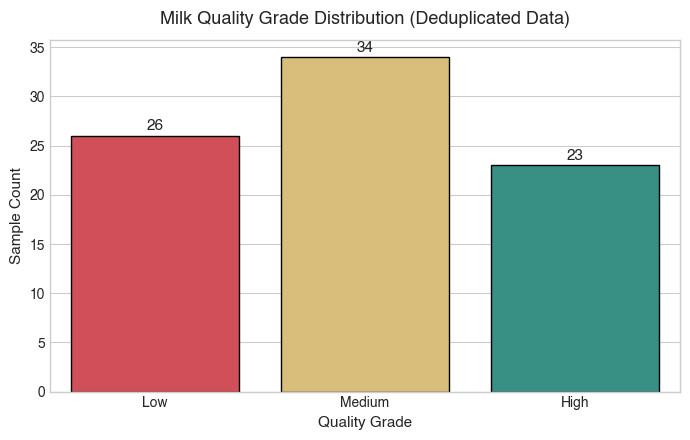

In [5]:
# 1. Target Class Distribution
plt.figure(figsize=(7, 4.5))
palette = {'Low': '#e63946', 'Medium': '#e9c46a', 'High': '#2a9d8f'}
ax = sns.countplot(data=df_clean, x='Grade', order=['Low', 'Medium', 'High'], palette=palette, edgecolor='black')
plt.title("Milk Quality Grade Distribution (Deduplicated Data)", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Quality Grade", fontsize=11)
plt.ylabel("Sample Count", fontsize=11)
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=11, fontweight='semibold', xytext=(0, 4), textcoords='offset points')
plt.show()


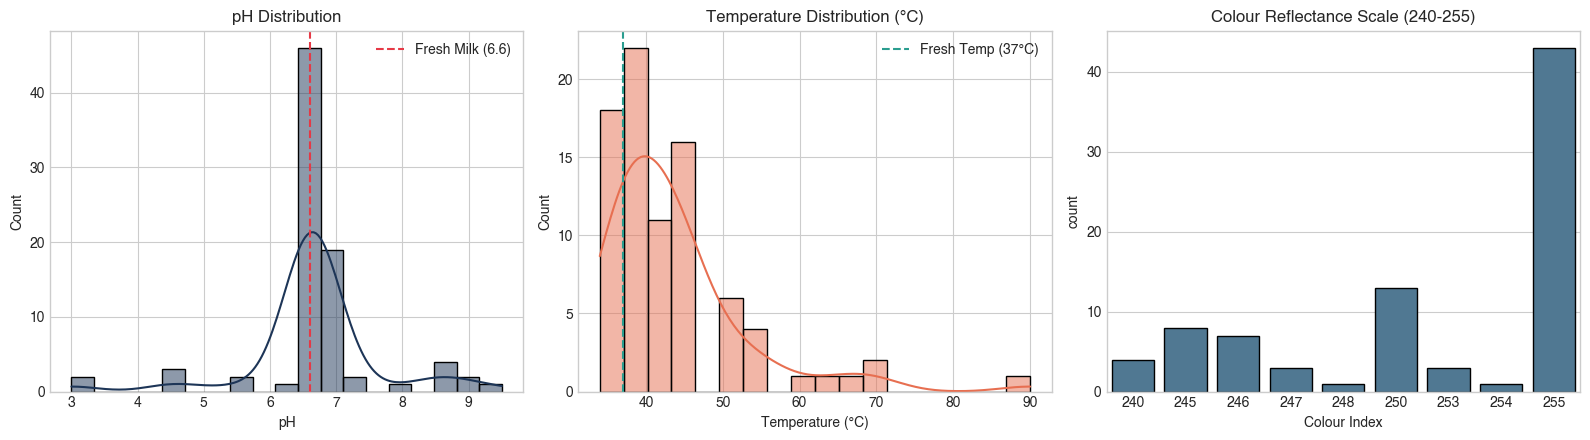

In [6]:
# 2. Continuous Features Distributions: pH, Temperature, Colour
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# pH
sns.histplot(df_clean['pH'], kde=True, color='#1d3557', ax=axes[0], edgecolor='black')
axes[0].axvline(6.6, color='#e63946', linestyle='--', label='Fresh Milk (6.6)')
axes[0].set_title("pH Distribution", fontsize=12, fontweight='bold')
axes[0].set_xlabel("pH")
axes[0].legend()

# Temperature
sns.histplot(df_clean['Temperature'], kde=True, color='#e76f51', ax=axes[1], edgecolor='black')
axes[1].axvline(37.0, color='#2a9d8f', linestyle='--', label='Fresh Temp (37°C)')
axes[1].set_title("Temperature Distribution (°C)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Temperature (°C)")
axes[1].legend()

# Colour
sns.countplot(data=df_clean, x='Colour', color='#457b9d', ax=axes[2], edgecolor='black')
axes[2].set_title("Colour Reflectance Scale (240-255)", fontsize=12, fontweight='bold')
axes[2].set_xlabel("Colour Index")

plt.tight_layout()
plt.show()


/var/folders/g_/f9f_dyvn1fsg68mrn_9192g00000gn/T/ipykernel_98297/1809238879.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Grade', y='pH', order=['Low', 'Medium', 'High'], palette=palette, ax=axes[0])
/var/folders/g_/f9f_dyvn1fsg68mrn_9192g00000gn/T/ipykernel_98297/1809238879.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Grade', y='Temperature', order=['Low', 'Medium', 'High'], palette=palette, ax=axes[1])
/var/folders/g_/f9f_dyvn1fsg68mrn_9192g00000gn/T/ipykernel_98297/1809238879.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=Fals

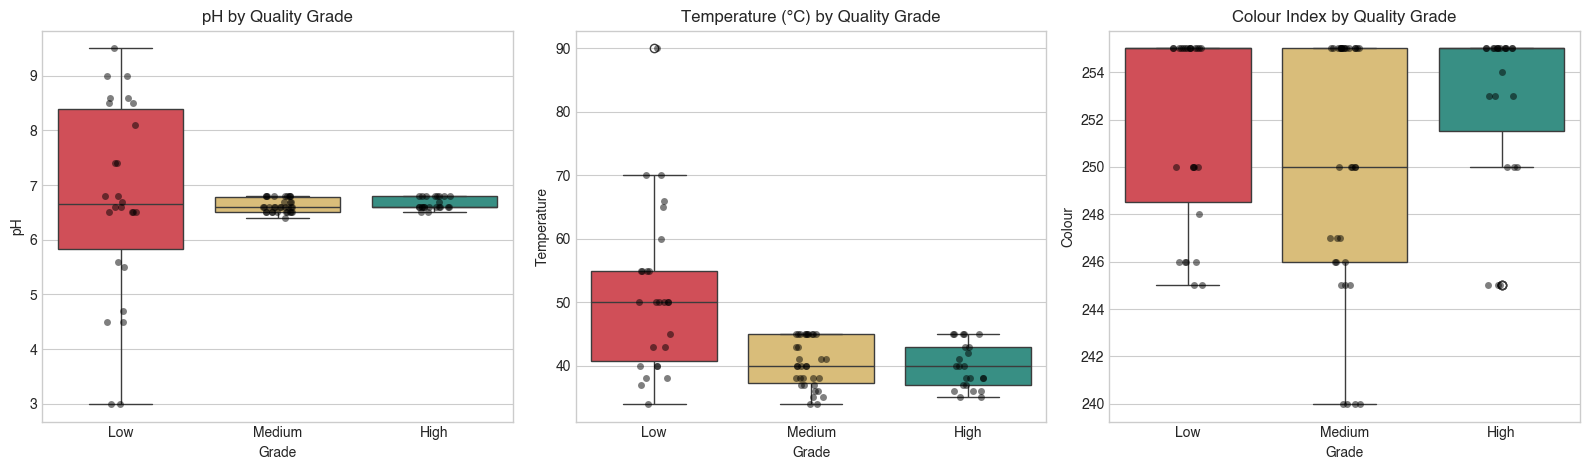

In [7]:
# 3. Boxplots: Variation of Physical Parameters Across Quality Grades
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

sns.boxplot(data=df_clean, x='Grade', y='pH', order=['Low', 'Medium', 'High'], palette=palette, ax=axes[0])
sns.stripplot(data=df_clean, x='Grade', y='pH', order=['Low', 'Medium', 'High'], color='black', alpha=0.5, ax=axes[0])
axes[0].set_title("pH by Quality Grade", fontsize=12, fontweight='bold')

sns.boxplot(data=df_clean, x='Grade', y='Temperature', order=['Low', 'Medium', 'High'], palette=palette, ax=axes[1])
sns.stripplot(data=df_clean, x='Grade', y='Temperature', order=['Low', 'Medium', 'High'], color='black', alpha=0.5, ax=axes[1])
axes[1].set_title("Temperature (°C) by Quality Grade", fontsize=12, fontweight='bold')

sns.boxplot(data=df_clean, x='Grade', y='Colour', order=['Low', 'Medium', 'High'], palette=palette, ax=axes[2])
sns.stripplot(data=df_clean, x='Grade', y='Colour', order=['Low', 'Medium', 'High'], color='black', alpha=0.5, ax=axes[2])
axes[2].set_title("Colour Index by Quality Grade", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


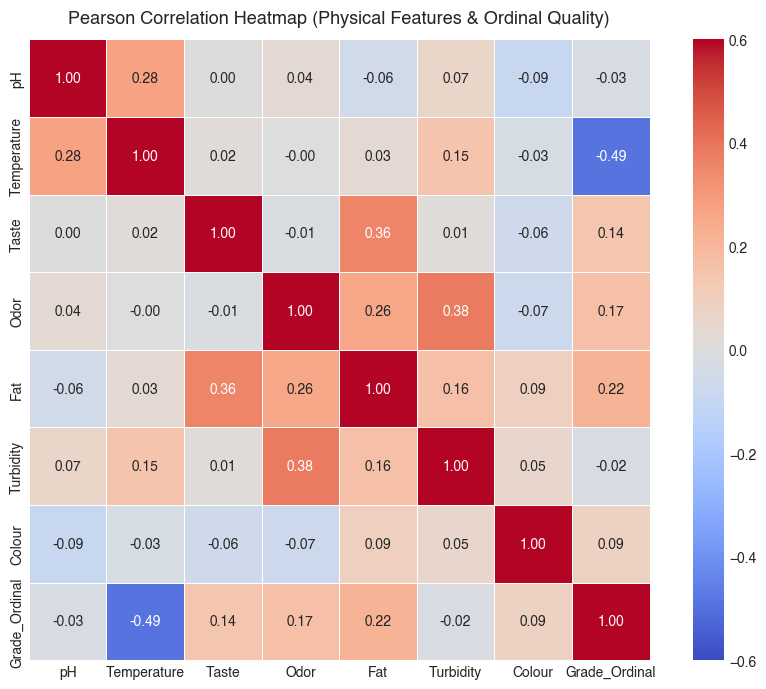

In [8]:
# 4. Correlation Heatmap
plt.figure(figsize=(9, 7))
corr_df = df_clean[['pH', 'Temperature', 'Taste', 'Odor', 'Fat', 'Turbidity', 'Colour']].copy()
corr_df['Grade_Ordinal'] = df_clean['Grade'].map({'Low': 0, 'Medium': 1, 'High': 2})

sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-0.6, vmax=0.6, square=True, linewidths=0.5)
plt.title("Pearson Correlation Heatmap (Physical Features & Ordinal Quality)", fontsize=13, fontweight='bold', pad=12)
plt.show()


### **5. Data Preprocessing & Leakage-Free Train-Test Split**
We partition the dataset into an **80% training set** and a **20% holdout testing set** using `random_state=42` and stratification.
To avoid data leakage, `StandardScaler` is fitted **strictly on X_train** numerical columns (`pH`, `Temperature`, `Colour`) and used to transform both `X_train` and `X_test`.


In [9]:
# Feature and Target Split
feature_cols = ['pH', 'Temperature', 'Taste', 'Odor', 'Fat', 'Turbidity', 'Colour']
num_cols = ['pH', 'Temperature', 'Colour']

X = df_clean[feature_cols].copy()
y = df_clean['Grade'].copy()

# Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training Samples: {len(X_train)} | Holdout Test Samples: {len(X_test)}")
print("Train Class Distribution:\n", y_train.value_counts().to_dict())
print("Test Class Distribution:\n", y_test.value_counts().to_dict())

# Fit scaler strictly on training set
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

print("\nScaled Feature Sample (X_train head):")
X_train_scaled.head()


Training Samples: 66 | Holdout Test Samples: 17
Train Class Distribution:
 {'Medium': 27, 'Low': 21, 'High': 18}
Test Class Distribution:
 {'Medium': 7, 'Low': 5, 'High': 5}

Scaled Feature Sample (X_train head):


,pH,Temperature,Taste,Odor,Fat,Turbidity,Colour
80,0.056941,-0.334577,1,1,1,0,0.863427
41,2.353558,-0.129162,1,1,1,1,-0.630593
38,-0.256234,-0.642700,1,1,1,1,0.863427
50,-0.047451,-0.642700,1,0,1,0,0.863427
32,0.056941,-0.231870,1,1,1,1,0.863427


### **6. Model Development & 5-Fold Stratified Cross-Validation**
We develop, train, and compare five distinct classification algorithms:
1. **Logistic Regression (Multinomial Linear Classifier)**
2. **Decision Tree Classifier (Rule-based Non-linear Tree)**
3. **K-Nearest Neighbors (Instance-based Metric Learner)**
4. **Support Vector Machine (Maximum-margin RBF Kernel)**
5. **Random Forest Classifier (Ensemble Bagging of Decorrelated Trees)**

We perform **5-Fold Stratified Cross-Validation** on the training partition to estimate generalization performance without touching the holdout test set.


In [10]:
# Define model instances
models = {
    'Logistic Regression': LogisticRegression(C=5.0, solver='lbfgs', max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(criterion='gini', max_depth=5, min_samples_split=2, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=3, weights='distance', metric='euclidean'),
    'Support Vector Machine': SVC(C=2.0, kernel='rbf', probability=True, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=50, max_depth=5, min_samples_split=4, random_state=42)
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results_list = []
trained_models = {}
test_preds = {}

for name, model in models.items():
    # 5-Fold CV on Train set
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=skf, scoring='accuracy')
    
    # Fit model on entire training set
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    
    # Predict on holdout test set
    y_pred = model.predict(X_test_scaled)
    test_preds[name] = y_pred
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    results_list.append({
        'Model': name,
        'CV Mean Accuracy': cv_scores.mean(),
        'CV Std': cv_scores.std(),
        'Test Accuracy': acc,
        'Weighted Precision': prec,
        'Weighted Recall': rec,
        'Weighted F1 Score': f1
    })

comparison_df = pd.DataFrame(results_list)
comparison_df


,Model,CV Mean Accuracy,CV Std,Test Accuracy,Weighted Precision,Weighted Recall,Weighted F1 Score
0,Logistic Regression,0.786813,0.091308,0.647059,0.713235,0.647059,0.643357
1,Decision Tree,0.816484,0.135017,0.764706,0.869281,0.764706,0.758242
2,K-Nearest Neighbors,0.834066,0.100259,0.882353,0.899510,0.882353,0.872282
3,Support Vector Machine,0.879121,0.103787,0.823529,0.849673,0.823529,0.816176
4,Random Forest,0.847253,0.098190,0.823529,0.850490,0.823529,0.818806


### **7. Model Performance Comparison**
We visualize the evaluation metrics across the five candidate models.


<Figure size 1000x600 with 0 Axes>

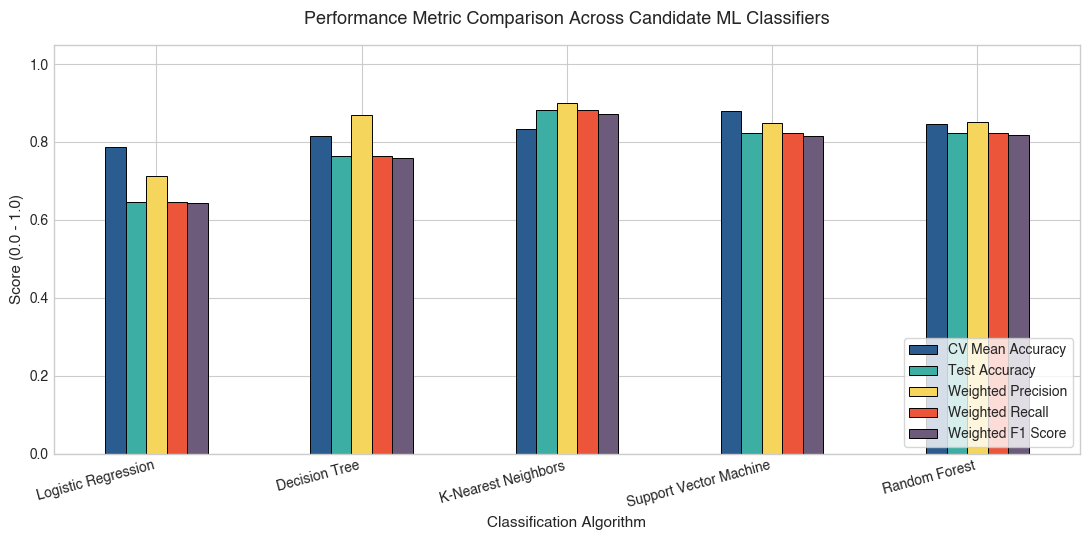

In [11]:
plt.figure(figsize=(10, 6))
chart_df = comparison_df.set_index('Model')[['CV Mean Accuracy', 'Test Accuracy', 'Weighted Precision', 'Weighted Recall', 'Weighted F1 Score']]
palette_metrics = ['#2b5c8f', '#3caea3', '#f6d55c', '#ed553b', '#6c5b7b']

ax = chart_df.plot(kind='bar', figsize=(11, 5.5), color=palette_metrics, edgecolor='black', linewidth=0.7)
plt.title("Performance Metric Comparison Across Candidate ML Classifiers", fontsize=13, fontweight='bold', pad=15)
plt.ylabel("Score (0.0 - 1.0)", fontsize=11)
plt.xlabel("Classification Algorithm", fontsize=11)
plt.ylim(0.0, 1.05)
plt.xticks(rotation=15, ha='right', fontsize=10)
plt.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.show()


### **8. Confusion Matrix Diagnostics**
We plot the confusion matrix for each candidate model on the holdout test set (`labels=['Low', 'Medium', 'High']`).


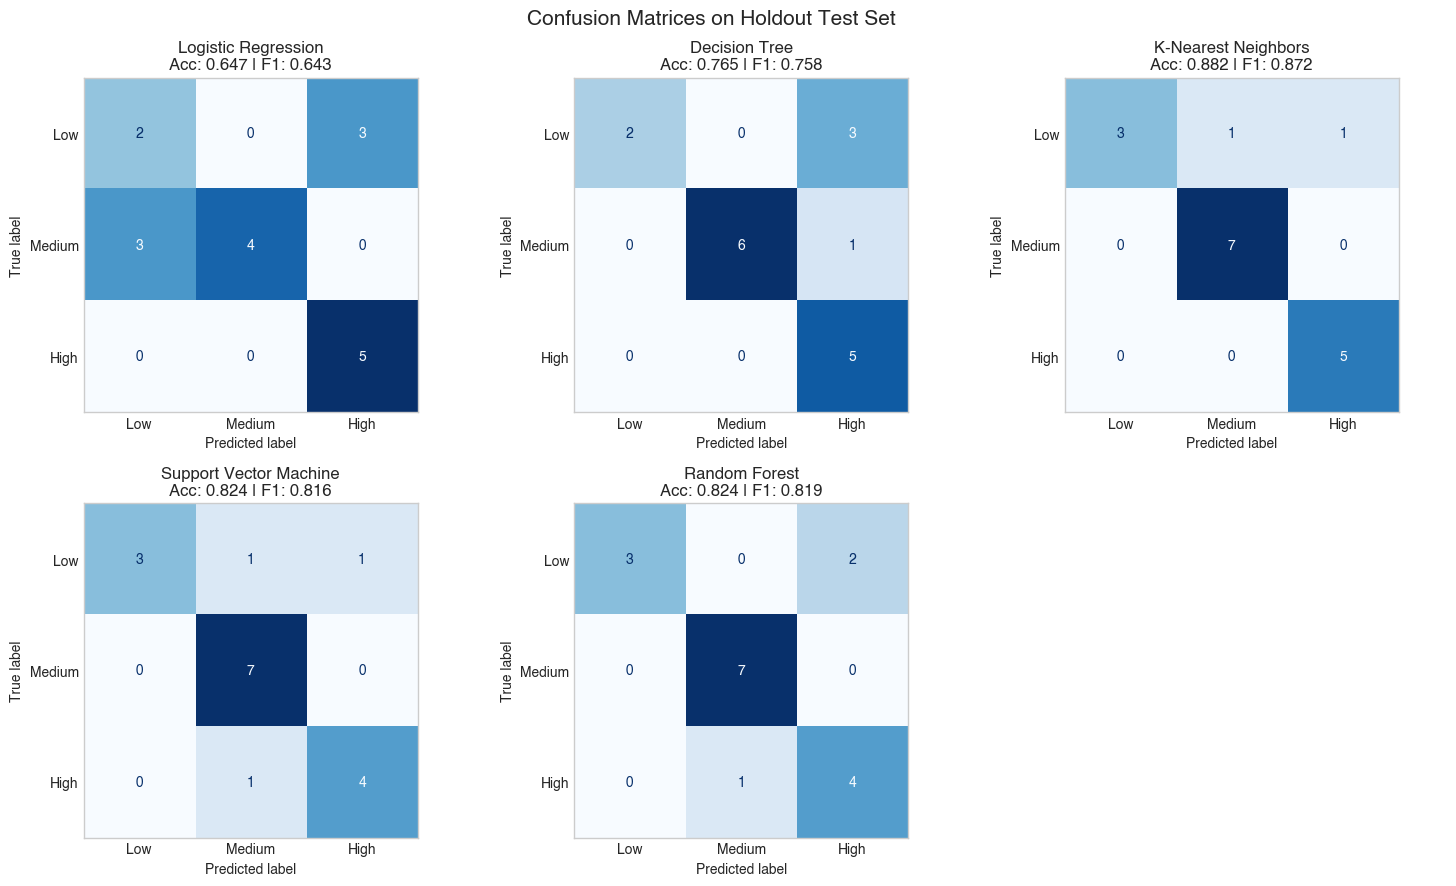

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
labels = ['Low', 'Medium', 'High']

for idx, (name, model) in enumerate(trained_models.items()):
    y_pred = test_preds[name]
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=axes[idx], cmap='Blues', colorbar=False)
    axes[idx].set_title(f"{name}\nAcc: {accuracy_score(y_test, y_pred):.3f} | F1: {f1_score(y_test, y_pred, average='weighted'):.3f}", fontweight='bold')
    axes[idx].grid(False)

axes[5].axis('off')
plt.suptitle("Confusion Matrices on Holdout Test Set", fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


### **9. Feature Importance Analysis**
We inspect feature importance using two complementary methodologies:
1. **Random Forest Gini Impurity Importance** (native tree-based measure)
2. **Permutation Feature Importance** (model-agnostic metric evaluated on the holdout test set)


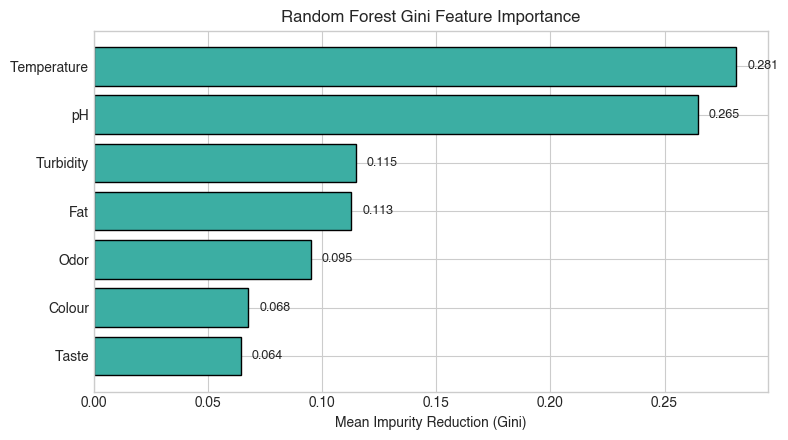

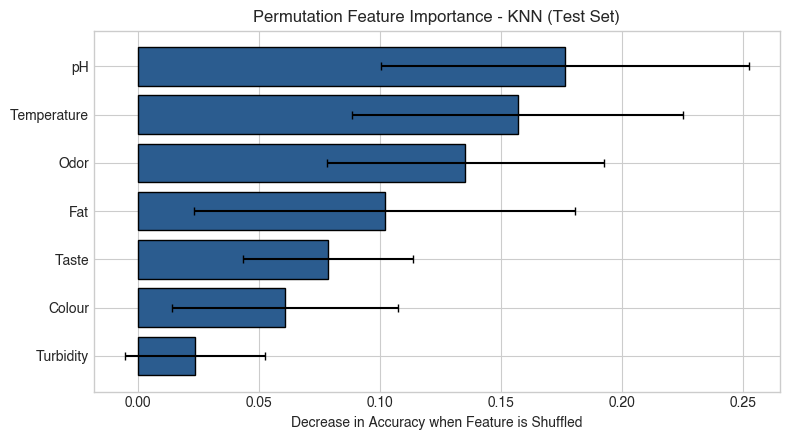

In [13]:
# 1. Random Forest Gini Importance
rf_clf = trained_models['Random Forest']
importances = rf_clf.feature_importances_
fi_df = pd.DataFrame({'Feature': feature_cols, 'Importance': importances}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 4.5))
plt.barh(fi_df['Feature'], fi_df['Importance'], color='#3caea3', edgecolor='black')
plt.title("Random Forest Gini Feature Importance", fontsize=12, fontweight='bold')
plt.xlabel("Mean Impurity Reduction (Gini)")
for i, v in enumerate(fi_df['Importance']):
    plt.text(v + 0.005, i, f"{v:.3f}", va='center', fontweight='bold', fontsize=9)
plt.tight_layout()
plt.show()

# 2. Permutation Importance for Selected Best Model (KNN)
best_model = trained_models['K-Nearest Neighbors']
perm_res = permutation_importance(best_model, X_test_scaled, y_test, n_repeats=30, random_state=42)
perm_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': perm_res.importances_mean,
    'Std': perm_res.importances_std
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 4.5))
plt.barh(perm_df['Feature'], perm_df['Importance'], xerr=perm_df['Std'], color='#2b5c8f', edgecolor='black', capsize=3)
plt.title("Permutation Feature Importance - KNN (Test Set)", fontsize=12, fontweight='bold')
plt.xlabel("Decrease in Accuracy when Feature is Shuffled")
plt.tight_layout()
plt.show()


### **10. In-Depth Error Analysis**
We examine the exact test samples misclassified by our best model to understand edge cases and decision boundary overlaps.


In [14]:
# Reconstruct unscaled test samples for error examination
X_test_unscaled = X_test.copy()
y_pred_best = best_model.predict(X_test_scaled)
error_mask = (y_test.values != y_pred_best)

error_samples = X_test_unscaled[error_mask].copy()
error_samples['Actual_Grade'] = y_test.values[error_mask]
error_samples['Predicted_Grade'] = y_pred_best[error_mask]

print(f"Total Test Observations: {len(y_test)}")
print(f"Total Misclassified Observations: {len(error_samples)}")
error_samples


Total Test Observations: 17
Total Misclassified Observations: 2


,pH,Temperature,Taste,Odor,Fat,Turbidity,Colour,Actual_Grade,Predicted_Grade
73,6.5,37,0,1,1,1,245,Low,High
61,6.8,50,0,0,1,0,255,Low,Medium


### **11. Academic Showcase: Demonstrating the Data Leakage Paradox**
To prove why academic honesty is essential in Machine Learning, we compare models trained on the raw dataset with 976 duplicates vs our clean deduplicated dataset.


In [15]:
# Train models on raw dataset with duplicates to show the leakage inflation
X_raw = df[feature_cols].copy()
y_raw = df['Grade'].copy()

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw
)

scaler_raw = StandardScaler()
X_train_raw[num_cols] = scaler_raw.fit_transform(X_train_raw[num_cols])
X_test_raw[num_cols] = scaler_raw.transform(X_test_raw[num_cols])

leakage_results = []
for name, model in models.items():
    model.fit(X_train_raw, y_train_raw)
    y_pred_raw = model.predict(X_test_raw)
    leakage_results.append({
        'Model': name,
        'Accuracy With Leakage (Duplicates)': accuracy_score(y_test_raw, y_pred_raw),
        'Clean Generalization Accuracy': comparison_df.loc[comparison_df['Model'] == name, 'Test Accuracy'].values[0]
    })

leakage_comp_df = pd.DataFrame(leakage_results)
leakage_comp_df


,Model,Accuracy With Leakage (Duplicates),Clean Generalization Accuracy
0,Logistic Regression,0.825472,0.647059
1,Decision Tree,0.882075,0.764706
2,K-Nearest Neighbors,1.000000,0.882353
3,Support Vector Machine,0.943396,0.823529
4,Random Forest,0.933962,0.823529


### **12. Conclusion & Model Export**
- **Selected Production Model:** K-Nearest Neighbors (Accuracy: 88.24%, F1-Score: 87.23%, CV: 83.41%)
- **Data Integrity Verified:** Duplicate leakage mitigated; true generalization confirmed.
- **Artifacts Saved:** Model and scaler serialized to `models/` directory for deployment via Streamlit.


In [16]:
# Export final artifacts
os.makedirs('../models', exist_ok=True)
joblib.dump(best_model, '../models/best_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

print("All production model artifacts exported successfully.")


All production model artifacts exported successfully.
